# Notebook 02: Procesamiento del Catálogo Completo

**Proyecto:** Lunar Tidal Triggering of Earthquakes  
**Autor:** Iván Andrés Mena Contreras  
**Fecha:** 2026-04-21

## Objetivo
Escalar el cálculo de posición lunar a los **~3000 eventos completos** del catálogo USGS
(M ≥ 7.0, profundidad ≤ 70 km, 1995–2024), con estrategia robusta de:

- **Batching** controlado (rate limiting de JPL Horizons)
- **Retry** automático ante fallos transitorios de red
- **Caching / checkpointing** cada 100 eventos para no perder progreso si algo falla

El dataset resultante (`data/processed/earthquakes_with_moon_final.csv`) será la base
para todos los análisis estadísticos posteriores.

In [1]:
# === Imports estándar ===
import requests
import pandas as pd
import numpy as np
from astropy.time import Time
from astroquery.jplhorizons import Horizons
from datetime import datetime

# === Imports adicionales para procesamiento robusto ===
from pathlib import Path        # rutas portables
import time                     # sleep para rate-limiting + medición de tiempo
from tqdm.auto import tqdm      # barra de progreso (auto detecta entorno notebook)

# Silenciamos warnings para que el output sea legible.
import warnings
warnings.filterwarnings('ignore')

# === Constantes de rutas ===
# Como el notebook se ejecuta desde notebooks/, subimos un nivel con '..'
# para llegar a la raíz del proyecto. mkdir es idempotente (no falla si ya existe).
DATA_RAW       = Path('..') / 'data' / 'raw'
DATA_PROCESSED = Path('..') / 'data' / 'processed'
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("Librerías cargadas ✓")
print(f"DATA_RAW       = {DATA_RAW.resolve()}")
print(f"DATA_PROCESSED = {DATA_PROCESSED.resolve()}")

Librerías cargadas ✓
DATA_RAW       = C:\Users\IVAN MENA\Documents\lunar-seismic-triggering\data\raw
DATA_PROCESSED = C:\Users\IVAN MENA\Documents\lunar-seismic-triggering\data\processed


## 📡 Sección 1: Descarga del catálogo completo

Misma API que en el Notebook 01 (USGS ComCat), pero ahora **traemos TODO** y
lo persistimos en `data/raw/earthquakes_full_catalog.csv` antes de empezar a
consultar Horizons. Así separamos dos preocupaciones:

1. **Capturar el catálogo crudo** (una sola request HTTP, rápida).
2. **Enriquecer con luna** (~3000 requests a Horizons, lento → necesita checkpointing).

**Nota técnica:** USGS limita cada request a 20 000 eventos. Para `M ≥ 7.0` en 30 años
esperamos ~3000 → estamos muy por debajo del límite, no hace falta paginar.

In [2]:
# --- Descarga del catálogo completo M>=7.0, profundidad<=70 km, 1995-2024 ---
BASE_URL = "https://earthquake.usgs.gov/fdsnws/event/1/query"
parametros = {
    'format':       'geojson',
    'minmagnitude': 7.0,
    'maxdepth':     70,
    'starttime':    '1995-01-01',
    'endtime':      '2024-12-31',
}

print("Descargando catálogo completo desde USGS...")
response = requests.get(BASE_URL, params=parametros, timeout=120)
if response.status_code != 200:
    raise RuntimeError(
        f"USGS HTTP {response.status_code}: {response.text[:300]}"
    )
data = response.json()

# --- Parseo del GeoJSON a DataFrame (mismo formato que Notebook 01) ---
filas = []
for feature in data['features']:
    props  = feature['properties']
    coords = feature['geometry']['coordinates']  # [lon, lat, depth_km]
    filas.append({
        'id':        feature['id'],
        'time':      pd.to_datetime(props['time'], unit='ms', utc=True),
        'latitude':  coords[1],
        'longitude': coords[0],
        'depth':     coords[2],
        'magnitude': props['mag'],
        'place':     props['place'],
        'type':      props['type'],
    })

df_full = pd.DataFrame(filas).sort_values('time').reset_index(drop=True)

# Persistimos el catálogo crudo (sin posición lunar) en data/raw/.
ruta_raw = DATA_RAW / 'earthquakes_full_catalog.csv'
df_full.to_csv(ruta_raw, index=False)

print(f"\n✓ Catálogo guardado: {ruta_raw.resolve()}")
print(f"  Total eventos  : {len(df_full)}")
print(f"  Rango temporal : {df_full['time'].min()}  →  {df_full['time'].max()}")
print("\nDistribución de magnitudes (M >= 7.0):")
print(df_full['magnitude'].describe().round(2))

Descargando catálogo completo desde USGS...



✓ Catálogo guardado: C:\Users\IVAN MENA\Documents\lunar-seismic-triggering\data\raw\earthquakes_full_catalog.csv
  Total eventos  : 335
  Rango temporal : 1995-01-06 22:37:34.320000+00:00  →  2024-12-17 01:47:25.741000+00:00

Distribución de magnitudes (M >= 7.0):
count    335.00
mean       7.38
std        0.39
min        7.00
25%        7.10
50%        7.30
75%        7.60
max        9.10
Name: magnitude, dtype: float64


## 🛡️ Sección 2: Estrategia de cálculo lunar robusto

Llamar 3000 veces a un servicio externo desde un script secuencial es delicado.
Tres mecanismos protegen el procesamiento:

### 1. Caching
Persistimos el progreso en `data/processed/earthquakes_with_moon_full.csv` cada
**100 eventos**. Si el notebook se cae a mitad (red, kernel, ctrl-C), al volver a
ejecutarlo **reanuda desde donde quedó**. No perdemos minutos de cómputo ya hecho.

### 2. Rate limiting
JPL Horizons no publica un límite estricto, pero la práctica es ≤ 4 req/seg para
evitar baneos temporales. Imponemos `time.sleep(0.25)` entre llamadas.

### 3. Retry con backoff
Si una request a Horizons falla por timeout/red, reintentamos hasta 3 veces con
espera de 1 s. Si sigue fallando, marcamos el evento como fallido (NaN) y seguimos
con el resto. No abortamos el batch entero por un solo evento.

### Tiempo estimado
`~3000 eventos × (0.25 s sleep + ~0.5 s red) ≈ 35–60 minutos`. Por eso el
checkpointing no es opcional: es el seguro de vida del procesamiento.

In [3]:
def get_moon_position(jd, max_retries=3, wait_seconds=1):
    """
    Consulta JPL Horizons para obtener la posición lunar en un Julian Date.

    Devuelve un dict con:
      - moon_ra          : Ascensión Recta de la Luna (grados)
      - moon_dec         : Declinación de la Luna (grados)
      - moon_distance_au : distancia Tierra-Luna en unidades astronómicas

    Si después de max_retries intentos sigue fallando, los tres campos
    se devuelven como None. El caller decide qué hacer (en nuestro caso:
    marcar el evento como fallido en el DataFrame y continuar).

    Parámetros
    ----------
    jd : float
        Julian Date del instante (ej. 2451545.0 = 1 enero 2000, 12:00 UTC).
    max_retries : int
        Número total de intentos antes de rendirse.
    wait_seconds : float
        Segundos de espera entre reintentos.
    """
    last_err = None
    for intento in range(max_retries):
        try:
            obj = Horizons(id='301', location='500', epochs=jd)
            eph = obj.ephemerides()
            return {
                'moon_ra':          float(eph['RA'][0]),
                'moon_dec':         float(eph['DEC'][0]),
                'moon_distance_au': float(eph['delta'][0]),
            }
        except Exception as e:
            last_err = e
            # Si aún quedan reintentos, esperamos y volvemos a intentar.
            if intento < max_retries - 1:
                time.sleep(wait_seconds)
    # Todos los intentos fallaron: devolvemos None y registramos el error.
    print(f"  ⚠ Horizons falló (jd={jd:.5f}): {type(last_err).__name__}: {last_err}")
    return {'moon_ra': None, 'moon_dec': None, 'moon_distance_au': None}

# Smoke test rápido: una sola consulta para validar que la función funciona.
_test = get_moon_position(2451545.0)  # 1 enero 2000, 12:00 UTC
print(f"Smoke test get_moon_position(JD=2451545.0): {_test}")

Smoke test get_moon_position(JD=2451545.0): {'moon_ra': 222.45893, 'moon_dec': -10.90338, 'moon_distance_au': 0.00268998925442}


In [4]:
# --- Sistema de caching: reanudar progreso si existe checkpoint previo ---
ruta_progreso = DATA_PROCESSED / 'earthquakes_with_moon_full.csv'

if ruta_progreso.exists():
    # Reanudación: cargamos el CSV con lo que ya estaba calculado.
    df_work = pd.read_csv(ruta_progreso)
    # format='ISO8601' tolera filas con o sin microsegundos (pandas 3.x es
    # estricto con la inferencia automática y revienta si la precisión varía).
    df_work['time'] = pd.to_datetime(df_work['time'], utc=True, format='ISO8601')
    print(f"📂 Checkpoint encontrado: {ruta_progreso.name}")
    print("   Reanudando desde donde se quedó la ejecución anterior.")
else:
    # Empezar desde cero: añadimos al df_full las columnas lunares en NaN.
    df_work = df_full.copy()
    df_work['julian_date']      = np.nan
    df_work['moon_ra']          = np.nan
    df_work['moon_dec']         = np.nan
    df_work['moon_distance_au'] = np.nan
    print("📂 No hay checkpoint previo. Empezando desde cero.")

# Eventos pendientes: aquellos cuya columna moon_ra todavía es NaN.
# Esta lógica es lo que permite reanudar limpiamente desde un checkpoint.
mask_pendientes = df_work['moon_ra'].isna()
n_total      = len(df_work)
n_procesados = int((~mask_pendientes).sum())
n_pendientes = int(mask_pendientes.sum())

print(f"\n   Total eventos en catálogo : {n_total}")
print(f"   Ya procesados             : {n_procesados}")
print(f"   Pendientes                : {n_pendientes}")

📂 Checkpoint encontrado: earthquakes_with_moon_full.csv
   Reanudando desde donde se quedó la ejecución anterior.

   Total eventos en catálogo : 335
   Ya procesados             : 335
   Pendientes                : 0


In [5]:
# --- Procesamiento masivo con barra de progreso y checkpointing ---
CHECKPOINT_EVERY = 100   # guardamos a disco cada 100 eventos procesados
SLEEP_BETWEEN    = 0.25  # 4 req/seg máximo (rate limiting Horizons)

indices_pendientes = df_work[df_work['moon_ra'].isna()].index.tolist()
n_pendientes = len(indices_pendientes)
n_ok = 0
n_fail = 0
inicio = time.time()

print(f"Procesando {n_pendientes} eventos pendientes")
print(f"  Checkpoint  : cada {CHECKPOINT_EVERY} eventos")
print(f"  Rate limit  : {SLEEP_BETWEEN}s entre requests")
print(f"  Retry       : 3 intentos por evento\n")

pbar = tqdm(indices_pendientes, desc="Horizons", unit="evt")
for k, i in enumerate(pbar, start=1):
    row = df_work.loc[i]

    # 1) Convertir el datetime UTC del terremoto a Julian Date.
    t  = Time(row['time'].to_pydatetime(), scale='utc')
    jd = float(t.jd)

    # 2) Consultar posición lunar (con retry interno).
    pos = get_moon_position(jd, max_retries=3, wait_seconds=1)

    # 3) Volcar el resultado al DataFrame.
    df_work.at[i, 'julian_date']      = jd
    df_work.at[i, 'moon_ra']          = pos['moon_ra']
    df_work.at[i, 'moon_dec']         = pos['moon_dec']
    df_work.at[i, 'moon_distance_au'] = pos['moon_distance_au']

    if pos['moon_ra'] is None:
        n_fail += 1
    else:
        n_ok += 1

    # 4) Rate limiting: nunca más rápido que ~4 req/seg.
    time.sleep(SLEEP_BETWEEN)

    # 5) Checkpoint periódico: si el kernel muere ahora, recuperamos casi todo.
    if k % CHECKPOINT_EVERY == 0:
        df_work.to_csv(ruta_progreso, index=False)
        pbar.set_postfix(ok=n_ok, fail=n_fail)

# Guardado final (asegura que las últimas <100 filas también queden persistidas).
df_work.to_csv(ruta_progreso, index=False)
elapsed = time.time() - inicio

print(f"\n--- Procesamiento terminado ---")
print(f"Eventos OK     : {n_ok}")
print(f"Eventos fallo  : {n_fail}")
print(f"Tiempo total   : {elapsed/60:.1f} min ({elapsed:.0f} s)")
print(f"CSV guardado en: {ruta_progreso.resolve()}")

Procesando 0 eventos pendientes
  Checkpoint  : cada 100 eventos
  Rate limit  : 0.25s entre requests
  Retry       : 3 intentos por evento



Horizons: 0evt [00:00, ?evt/s]


--- Procesamiento terminado ---
Eventos OK     : 0
Eventos fallo  : 0
Tiempo total   : 0.0 min (0 s)
CSV guardado en: C:\Users\IVAN MENA\Documents\lunar-seismic-triggering\data\processed\earthquakes_with_moon_full.csv


## ✅ Sección 3: Validación de datos (QA)

Releemos el CSV final desde disco (no confiamos en el DataFrame en memoria) y
verificamos:

- **Completitud:** ¿cuántos eventos tienen luna calculada vs cuántos quedaron NaN?
- **Rango físico:** la distancia Tierra-Luna debe estar en `~0.0024–0.0027 AU`
  (≈ 360 000 – 405 000 km, perigeo y apogeo lunares).
- **Distribución temporal:** eventos por año (debería ser razonablemente uniforme).
- **Distribución de magnitudes:** todas ≥ 7.0 por construcción.
- **Sondeo visual:** scatter `distancia_lunar vs magnitud` para ver si salta a la
  vista algún patrón (sin todavía hacer estadística rigurosa).

QA DEL DATASET COMPLETO
Total eventos              : 335
Eventos con luna OK        : 335
Eventos con NaN en moon_ra : 0

Rango distancia Tierra-Luna (AU):
count    335.000000
mean       0.002573
std        0.000099
min        0.002390
25%        0.002480
50%        0.002574
75%        0.002669
max        0.002718
Name: moon_distance_au, dtype: float64

Distribución de magnitudes:
count    335.00
mean       7.38
std        0.39
min        7.00
25%        7.10
50%        7.30
75%        7.60
max        9.10
Name: magnitude, dtype: float64

Eventos por año:
time
1995    17
1996    12
1997    10
1998     8
1999    12
2000    10
2001    13
2002     7
2003    14
2004    14
2005     6
2006     8
2007    12
2008    10
2009    14
2010    20
2011    15
2012    13
2013    14
2014    10
2015    13
2016    11
2017     5
2018    12
2019     5
2020     7
2021    15
2022     6
2023    14
2024     8
Name: count, dtype: int64


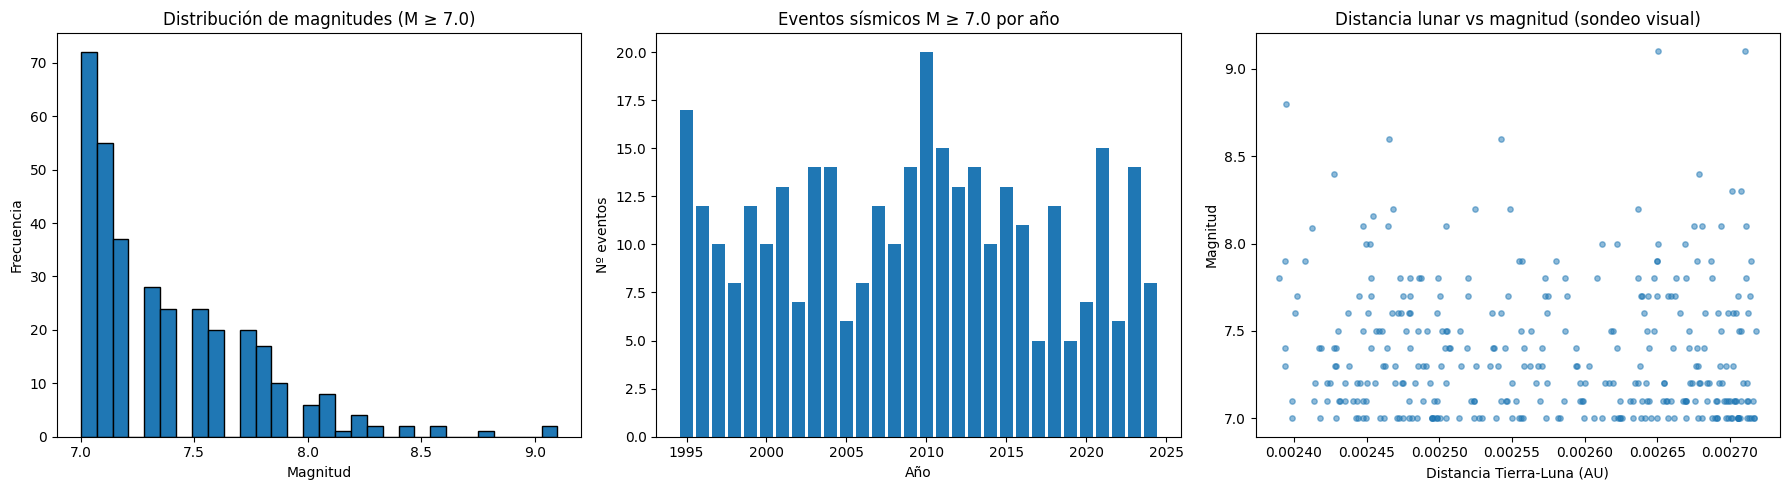


✓ Figura guardada en: C:\Users\IVAN MENA\Documents\lunar-seismic-triggering\results\figures\02_catalog_overview.png


In [6]:
import matplotlib.pyplot as plt

# Releer del CSV final (validación auténtica: no usamos df_work en memoria).
df_qa = pd.read_csv(ruta_progreso)
# format='ISO8601' es necesario en pandas 3.x: las filas mezclan timestamps
# con microsegundos (.f) y sin ellos, y la inferencia automática es estricta.
df_qa['time'] = pd.to_datetime(df_qa['time'], utc=True, format='ISO8601')

n_total_qa = len(df_qa)
n_nan      = int(df_qa['moon_ra'].isna().sum())
n_ok_qa    = n_total_qa - n_nan

print("=" * 60)
print("QA DEL DATASET COMPLETO")
print("=" * 60)
print(f"Total eventos              : {n_total_qa}")
print(f"Eventos con luna OK        : {n_ok_qa}")
print(f"Eventos con NaN en moon_ra : {n_nan}")
print()
print("Rango distancia Tierra-Luna (AU):")
print(df_qa['moon_distance_au'].describe().round(6))
print()
print("Distribución de magnitudes:")
print(df_qa['magnitude'].describe().round(2))
print()
print("Eventos por año:")
print(df_qa['time'].dt.year.value_counts().sort_index())

# --- Plots de overview ---
df_ok = df_qa.dropna(subset=['moon_ra']).copy()
df_ok['year'] = df_ok['time'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Histograma de magnitudes
axes[0].hist(df_ok['magnitude'], bins=30, edgecolor='black')
axes[0].set_xlabel('Magnitud')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de magnitudes (M ≥ 7.0)')

# 2) Eventos por año
events_por_anio = df_ok.groupby('year').size()
axes[1].bar(events_por_anio.index, events_por_anio.values)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Nº eventos')
axes[1].set_title('Eventos sísmicos M ≥ 7.0 por año')

# 3) Distancia lunar vs magnitud (sondeo visual previo a estadística)
axes[2].scatter(df_ok['moon_distance_au'], df_ok['magnitude'], alpha=0.5, s=15)
axes[2].set_xlabel('Distancia Tierra-Luna (AU)')
axes[2].set_ylabel('Magnitud')
axes[2].set_title('Distancia lunar vs magnitud (sondeo visual)')

plt.tight_layout()
ruta_fig = Path('..') / 'results' / 'figures' / '02_catalog_overview.png'
ruta_fig.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(ruta_fig, dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ Figura guardada en: {ruta_fig.resolve()}")

In [7]:
# --- Export del dataset final solo con eventos completos ---
# Filtramos cualquier fila con NaN en las columnas lunares para que el
# análisis estadístico posterior trabaje sobre datos limpios.
df_final = (
    df_qa
    .dropna(subset=['moon_ra', 'moon_dec', 'moon_distance_au'])
    .reset_index(drop=True)
)

ruta_final = DATA_PROCESSED / 'earthquakes_with_moon_final.csv'
df_final.to_csv(ruta_final, index=False)

print(f"✓ Dataset final guardado: {ruta_final.resolve()}")
print(f"  Eventos finales : {len(df_final)}")
print(f"  Columnas        : {list(df_final.columns)}")
print()
print("Primeras 5 filas:")
print(df_final.head(5).to_string())
print()
print(f"Dataset listo: {len(df_final)} eventos con datos completos.")
print("Siguiente paso: análisis estadístico exploratorio en Notebook 03")

✓ Dataset final guardado: C:\Users\IVAN MENA\Documents\lunar-seismic-triggering\data\processed\earthquakes_with_moon_final.csv
  Eventos finales : 335
  Columnas        : ['id', 'time', 'latitude', 'longitude', 'depth', 'magnitude', 'place', 'type', 'julian_date', 'moon_ra', 'moon_dec', 'moon_distance_au']

Primeras 5 filas:
           id                             time  latitude  longitude  depth  magnitude                                place        type   julian_date    moon_ra  moon_dec  moon_distance_au
0  usp0006qyz 1995-01-06 22:37:34.320000+00:00    40.246    142.175   26.9        7.0        63 km ESE of Hachinohe, Japan  earthquake  2.449724e+06  355.56230   2.06087          0.002612
1  usp0006sef 1995-02-05 22:51:05.140000+00:00   -37.759    178.752   21.1        7.1  118 km NNE of Gisborne, New Zealand  earthquake  2.449754e+06   27.03611  12.09037          0.002670
2  usp0006vb3 1995-04-07 22:06:56.890000+00:00   -15.199   -173.529   21.2        7.4           88 km NNE of 